In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from modified_rf import RandomForestRegressor621

np.random.seed(24)

In [2]:
def read_label_data(name, ID):
    data = pd.read_csv(name)
    data
    X = data.iloc[0:,2:].to_numpy()
    X = np.column_stack((X,[ID]*len(X)))
    y = data.iloc[0:,1].to_numpy()
    return X, y

In [3]:
X, y = read_label_data('Data/TMB_F1CDX_data.xlsx - thca_tcga_pub.csv', 0)

Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - blca_tcga_pub.csv', 1)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - ov_tcga_pub.csv', 2)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - kich_tcga_pub.csv', 3)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - coadread_tcga_pub.csv', 4)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - kirc_tcga_pub.csv', 5)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - sarc_tcga_pub.csv', 6)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - brca_tcga_pub.csv', 7)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - hnsc_tcga_pub.csv', 9)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - ucec_tcga_pub.csv', 10)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - luad_tcga_pub.csv', 11)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - lusc_tcga_pub.csv', 12)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - gbm_tcga_pub.csv', 13)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)
Xtemp, ytemp = read_label_data('Data/TMB_F1CDX_data.xlsx - prad_tcga_pub.csv', 14)
X = np.concatenate((X,Xtemp), axis = 0)
y = np.concatenate((y,ytemp), axis = 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)
print(X_train[:,-1])

[ 5. 14.  7. ...  7.  2.  0.]


In [4]:
def forest(label_depth):
    rf1 = RandomForestRegressor621(n_estimators=600, min_samples_leaf=10, max_features=0.2, max_depth=None, label_depth=label_depth, force_label_split=False, oob_score=True)
    # Fit the model to the training data
    rf1.fit(X_train, y_train)

    # Make predictions on new data
    predictions = rf1.predict(X_test)

    # Calculate the accuracy score for the predictions
    accuracy_score = rf1.score(X_test, y_test)
    print("\n Test Accuracy:",accuracy_score)

    train_score = rf1.score(X_train, y_train)
    print("\n Training Accuracy:",train_score)
    
    return train_score, accuracy_score, rf1

In [5]:
depth = 25
test_scores = np.zeros(depth)
train_scores = np.zeros(depth)
forests = []
for i in range(0,depth):
    train_scores[i], test_scores[i], rfn = forest(i)
    forests = forests.append(rfn)
    print('Label depth',i)

KeyboardInterrupt: 

Text(0, 0.5, 'Test Accuracy')

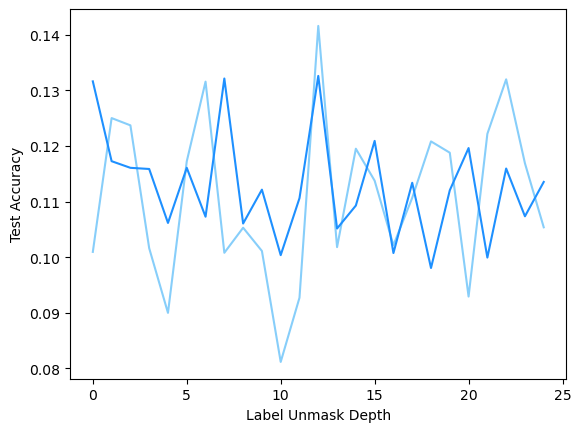

In [ ]:
plt.plot(np.arange(depth),test_scores, color = "lightskyblue")

#plt.legend()
plt.xlabel("Label Unmask Depth")
plt.ylabel("Test Accuracy")